In [90]:
import meshio as mio
import h5py
import numpy as np
import pyvista as pv
from ipywidgets import interact, interactive, fixed, interact_manual
from matplotlib.widgets import Button, Slider
from scipy.spatial.transform import Rotation
import ipywidgets as widgets
import scipy as sp
import matplotlib.pyplot as mplt
import matplotlib
import matplotlib.animation as animation
import json as js
import meshio as mio
import subprocess as sup
import math
import tifffile
from scipy.fft import fft, ifft, fftfreq
from scipy.interpolate import RBFInterpolator

pv.set_jupyter_backend('trame')
# pv.set_jupyter_backend('client')

In [2]:
def to_pyvista_mesh(V, F = None):
    if F is None:
        return pv.PolyData(V)
    if F.shape[1] == 3:
        return pv.UnstructuredGrid({pv.CellType.TRIANGLE: F}, V)
    elif F.shape[1] == 4:
        return pv.UnstructuredGrid({pv.CellType.TETRA: F}, V)

In [64]:
image = tifffile.imread("/Users/zoeli/Documents/UVic/masters/other/fish/Mask_3.tif")

# Print the shape and data type of the array
print(image[0].shape)
print(image.dtype)

(365, 901)
uint8


In [65]:
# path = "/Users/teseo/Downloads/Embryogram test/new/0in-analysis-07_09T15_10-analysis.hdf5"
# path = "/Users/teseo/Downloads/Embryogram test/20250510_tracking-analysis-07_19T18_47-analysis.hdf5"
# path = "/Users/zoeli/Documents/UVic/masters/other/fish/still.hdf5"
#path = "/Users/zoeli/Documents/UVic/masters/other/fish/neweststill.hdf5"

#o ct 16
#path = "/Users/zoeli/Documents/UVic/masters/other/fish/not_control.hdf5"

#o ct 10
#path = "/Users/zoeli/Documents/UVic/masters/other/fish/realone.hdf5"

# new 
path = "/Users/zoeli/Documents/UVic/masters/other/fish/20250523.hdf5"

# new 
#path = "/Users/zoeli/Documents/UVic/masters/other/fish/20250708.hdf5"
#path = "/Users/zoeli/Documents/UVic/masters/other/fish/20250702.hdf5"

#polyfem = "/Users/teseo/Documents/scuola/polyfem/polyfem.nosync/bin_rel.nosync/PolyFEM_bin"

In [66]:
hdf5_file = h5py.File(path, "r")
V, T = hdf5_file["mesh/v"][:].astype(float), hdf5_file["mesh/t"][:].astype(np.int32)

top = hdf5_file["bc/top"][:].astype(np.int32)
bottom = hdf5_file["bc/bottom"][:].astype(np.int32)
middle = hdf5_file["bc/middle"][:].astype(np.int32)

print(top, bottom, middle)

[   900    901    902 ... 170540 171364 171856] [  1800   1801   1802 ... 174015 177116 177158] [     0      1      2 ... 177097 177143 177144]


In [98]:
centers = hdf5_file["bc_func/centers"][:].astype(float)
eps = hdf5_file["bc_func/eps"][()]

In [68]:
nk = len(hdf5_file["bc_func"].keys())-2

disps = []

for i in range(nk):
    disps.append(hdf5_file[f"bc_func/disp{i+1}"][:].astype(float))

print(len(disps))

231


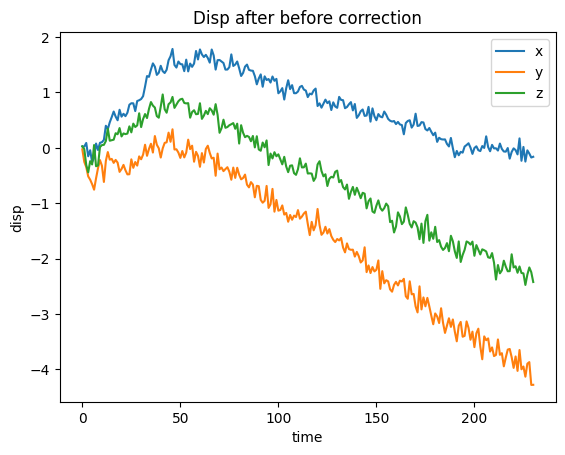

In [8]:
data = [np.mean(t[0]) for t in disps]
mplt.plot(data, label='x')
data = [np.mean(t[1]) for t in disps]
mplt.plot(data, label='y')
data = [np.mean(t[2]) for t in disps]
mplt.plot(data, label='z')
mplt.legend()
mplt.xlabel('time')
mplt.ylabel('disp')
mplt.title('Disp after before correction')
mplt.show()

In [69]:
E = hdf5_file["problem/E"][()] .astype(float)
nu = hdf5_file["problem/nu"][()] .astype(float)
is_linear = hdf5_file["problem/is_linear"][()] .astype(bool)

# E

In [70]:
print(centers.shape)
first_frame = image[180]
plt = pv.Plotter()
mesh = to_pyvista_mesh(centers)
mesh['mask'] = [first_frame[int(center[1] / 0.325)][int(center[0] / 0.325)] for center in centers]
print(int(centers[0][0] / 0.325))
plt.add_mesh(mesh, point_size=7, render_points_as_spheres=True, scalars='mask', cmap='winter')
plt.show()

(900, 3)
538


Widget(value='<iframe src="http://localhost:57369/index.html?ui=P_0x1cb63667290_13&reconnect=auto" class="pyvi…

In [71]:
neighbourhoods = []

for i, disps_per_frame in enumerate(disps):
    neighbourhoods_per_frame = []

    for j, disp in enumerate(disps_per_frame):
        distances = np.linalg.norm(centers - centers[j], axis=1)
        indices = np.argsort(distances)
        neighbourhood = indices[1:19]

        neighbourhoods_per_frame.append(neighbourhood)
    
    neighbourhoods.append(neighbourhoods_per_frame)

In [72]:
corrected_disps = np.array(disps)
corrected = [[0.0 for disp in disps_per_frame] for disps_per_frame in disps]

count = 1
num_time = 0

while count > 0 and num_time < 10:
    count = 0

    for i, disps_per_frame in enumerate(corrected_disps):
        for j, disp in enumerate(disps_per_frame):
            neighbourhood_disps = disps_per_frame[neighbourhoods[i][j]]

            neighbourhood_mean = np.mean(neighbourhood_disps, axis=0)
            neighbourhood_lengths = np.linalg.norm(neighbourhood_disps, axis=1)
            neighbourhood_length_mean = np.mean(neighbourhood_lengths)
            cosine_similarity = np.dot(neighbourhood_mean, disp) / (np.linalg.norm(neighbourhood_mean) * np.linalg.norm(disp))
            length_difference = abs(neighbourhood_length_mean - np.linalg.norm(disp))
            difference = np.linalg.norm(neighbourhood_mean - disp)

            if length_difference > 4.0:
                corrected_disps[i][j] = neighbourhood_mean
                corrected[i][j] = 1.0
                count += 1
            elif difference > 4.0:
                corrected_disps[i][j] = neighbourhood_mean
                corrected[i][j] = 1.0
                count += 1
            elif cosine_similarity < 0.9:
                corrected_disps[i][j] = neighbourhood_mean
                corrected[i][j] = 1.0
                count += 1
    
    num_time += 1
    print(num_time)

1
2
3
4
5
6
7


In [73]:
pl = pv.Plotter()
pl.add_mesh(to_pyvista_mesh(centers), color='blue', point_size=3, render_points_as_spheres=True, name='middle')

nd = disps[0].shape[0]
lines = np.hstack([[2, i, nd+i] for i in range(nd)])
corrected_lines = np.hstack([[2, i, nd+i] for i in range(nd)])

vertices = np.vstack([centers, centers + disps[0]])
ll = pv.PolyData(vertices, lines=lines)
ll['corrected'] = corrected[0]
pl.add_mesh(ll, name='line', scalars='corrected', cmap='bwr')

corrected_vertices = np.vstack([centers, centers + corrected_disps[0]])
corrected_ll = pv.PolyData(corrected_vertices, lines=corrected_lines)
corrected_ll['corrected'] = corrected[0]
pl.add_mesh(corrected_ll, name='corrected_line', scalars='corrected', cmap='winter')

def callback(x):
    vertices = np.vstack([centers, centers + disps[x]])
    ll = pv.PolyData(vertices, lines=lines)
    ll['corrected'] = corrected[x]
    pl.add_mesh(ll, name='line', scalars='corrected', cmap='bwr')

    corrected_vertices = np.vstack([centers, centers + corrected_disps[x]])
    corrected_ll = pv.PolyData(corrected_vertices, lines=corrected_lines)
    corrected_ll['corrected'] = corrected[x]
    pl.add_mesh(corrected_ll, name='corrected_line', scalars='corrected', cmap='winter')
    
    pl.update()

pl.show()
interact(callback, x=(0, len(disps)-1, 1))



Widget(value='<iframe src="http://localhost:57369/index.html?ui=P_0x1cb63667d40_14&reconnect=auto" class="pyvi…

interactive(children=(IntSlider(value=115, description='x', max=230), Output()), _dom_classes=('widget-interac…

<function __main__.callback(x)>

In [15]:
pl = pv.Plotter()
mesh = to_pyvista_mesh(centers)
mesh['mask'] = [image[0][int(center[1] / 0.325)][int(center[0] / 0.325)] for center in centers]
pl.add_mesh(mesh, point_size=7, render_points_as_spheres=True, scalars='mask', cmap='winter', name="uhhh")

#def callback(x):
#    current_points = centers + corrected_disps[x]
#    mesh = to_pyvista_mesh(current_points)
#    mesh['mask'] = [image[x][int(center[1] / 0.325)][int(center[0] / 0.325)] for center in current_points]
#    pl.add_mesh(mesh, point_size=7, render_points_as_spheres=True, scalars='mask', cmap='winter', name="uhhh")
#    pl.update()

pl.show()
#interact(callback, x=(0, len(disps)-1, 1))

Widget(value='<iframe src="http://localhost:57369/index.html?ui=P_0x1ca88f9bfb0_3&reconnect=auto" class="pyvis…

In [74]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=7)
knn.fit(centers[:,:2])
neighbors = knn.kneighbors(centers[:,:2], return_distance=False)

In [75]:
from tqdm import tqdm

new_disps = [p.copy() for p in corrected_disps]
n_frames = len(disps)
n_pts = len(centers)

for it in tqdm(range(200)):
    tmp = [p.copy() for p in new_disps]

    for fr in range(1, n_frames - 1):
        for j in range(n_pts):
            current_point = centers[j] + corrected_disps[fr][j]
            
            try:
                if image[fr][int(current_point[1] / 0.325)][int(current_point[0] / 0.325)] > 100:
                    continue
            except:
                continue

            neighbors_idxs = neighbors[j]
            avg_dispi = np.mean(new_disps[fr][neighbors_idxs], axis=0)
            avg_dispip = np.mean(new_disps[fr+1][neighbors_idxs], axis=0)
            avg_dispim = np.mean(new_disps[fr-1][neighbors_idxs], axis=0)
            # print(avg_dispi)
            tmp[fr][j] = (avg_dispi + avg_dispim + avg_dispip) / 3

    #print(np.array(new_disps[0]) - np.array(tmp[0]))
    #uhh = [np.average(np.linalg.norm(np.array(new_disps[i]) - np.array(tmp[i]), axis = 1)) for i in range(len(new_disps))]
    #print(np.average(uhh))
    new_disps = tmp

100%|██████████| 200/200 [03:03<00:00,  1.09it/s]


In [76]:
pl = pv.Plotter()
mesh = to_pyvista_mesh(centers)
mesh['mask'] = [disp[0] for disp in corrected_disps[0] - new_disps[0]]
pl.add_mesh(mesh, point_size=7, render_points_as_spheres=True, scalars='mask', cmap='winter', name="uhhh")

def callback(x):
    current_points = centers + new_disps[x]
    mesh = to_pyvista_mesh(centers)
    mesh['mask'] = [disp[2] for disp in corrected_disps[x] - new_disps[x]]
    pl.add_mesh(mesh, point_size=7, render_points_as_spheres=True, scalars='mask', cmap='winter', name="uhhh")
    pl.update()

pl.show()
interact(callback, x=(0, len(disps)-1, 1))

Widget(value='<iframe src="http://localhost:57369/index.html?ui=P_0x1cb635c0f80_15&reconnect=auto" class="pyvi…

interactive(children=(IntSlider(value=115, description='x', max=230), Output()), _dom_classes=('widget-interac…

<function __main__.callback(x)>

In [77]:
cells = [("vertex", np.array([[i,] for i in range(len(centers))]))]

for i, disp in enumerate(disps):
    current_points = centers + corrected_disps[i]
    mask = [image[i][int(point[1] / 0.325)][int(point[0] / 0.325)] for point in current_points]
    mesh = mio.Mesh(centers, cells, point_data={"corrected_disps": corrected_disps[i], "new_disps": new_disps[i], "mask": mask})
    path = "/Users/zoeli/Documents/UVic/masters/other/fish/vtuFiles/disps" + str(i) + ".vtu"
    mesh.write(path)

In [ ]:
rbf_disps = []

for i, disp in enumerate(disps):
    rbf = RBFInterpolator(centers, corrected_disps[i] - new_disps[i])
    rbf_disp = rbf(centers)
    rbf_disps.append(rbf_disp)

In [143]:
sorting_indexes = np.lexsort((centers[:,0], centers[:,1]))

cut = sorting_indexes[0:45]
i = 90
while (i < len(sorting_indexes)):
    if i % 180 != 45:
        i += 45
        continue
    
    cut = np.concatenate((cut, sorting_indexes[i - 45:i]))
    i += 45

sorting_indexes = np.lexsort((centers[:,1], centers[:,0]))

cut2 = sorting_indexes[0:20]
i = 40
while (i < len(sorting_indexes)):
    if i % 80 != 20:
        i += 20
        continue
    
    cut2 = np.concatenate((cut2, sorting_indexes[i - 20:i]))
    i += 20

finalcut = np.intersect1d(cut, cut2)

pl = pv.Plotter()
mesh = to_pyvista_mesh(centers[finalcut])
pl.add_mesh(mesh, point_size=7, render_points_as_spheres=True)
pl.show()

rbf_disps_fourth = []

for i, disp in enumerate(disps):
    rbf = RBFInterpolator(centers[finalcut], (corrected_disps[i] - new_disps[i])[finalcut])
    rbf_disp = rbf(centers)
    rbf_disps_fourth.append(rbf_disp)

Widget(value='<iframe src="http://localhost:57369/index.html?ui=P_0x1cb6353b680_53&reconnect=auto" class="pyvi…

In [147]:
pl = pv.Plotter()
mesh = to_pyvista_mesh(centers)
mesh['mask'] = [disp[0] for disp in rbf_disps[0]]
pl.add_mesh(mesh, point_size=7, render_points_as_spheres=True, scalars='mask', cmap='winter', name="uhhh")

def callback(x):
    mesh = to_pyvista_mesh(centers)
    mesh['mask'] = [disp[2] for disp in rbf_disps[x]]
    pl.add_mesh(mesh, point_size=7, render_points_as_spheres=True, scalars='mask', cmap='winter', name="uhhh")
    pl.update()

pl.show()
interact(callback, x=(0, len(rbf_disps)-1, 1))

Widget(value='<iframe src="http://localhost:57369/index.html?ui=P_0x1cc3ff901d0_55&reconnect=auto" class="pyvi…

interactive(children=(IntSlider(value=115, description='x', max=230), Output()), _dom_classes=('widget-interac…

<function __main__.callback(x)>

In [146]:
cells = [("vertex", np.array([[i,] for i in range(len(centers))]))]

for i, disp in enumerate(disps):
    current_points = centers + corrected_disps[i]
    mask = [image[i][int(point[1] / 0.325)][int(point[0] / 0.325)] for point in current_points]
    mesh = mio.Mesh(centers, cells, point_data={
        "corrected_disps": corrected_disps[i], 
        "new_disps": new_disps[i], 
        "mask": mask, 
        "rbf_disps_half": rbf_disps[i], 
        "rbf_disps_third": rbf_disps_third[i], 
        "rbf_disps_fourth": rbf_disps_fourth[i]
    })
    path = "/Users/zoeli/Documents/UVic/masters/other/fish/vtuFiles/disps" + str(i) + ".vtu"
    mesh.write(path)

[[ 0.28227099 -0.41038247  0.20906191]
 [-0.03885638  0.02346319  0.06840776]
 [ 0.11981139 -0.08009945  0.0861796 ]
 ...
 [ 0.03997307  0.05584269 -0.05456338]
 [ 0.06644069 -0.02835567  0.06568189]
 [ 0.20816668  0.01980155  0.00738453]]
[ -0.03885638  -0.06808962  -0.08853207  -0.29619949  -0.19156201
  -0.55589956  -0.77180412  -0.64611694   0.12473709   0.04067585
   0.09380407  -0.07933677  -0.13674281  -0.29879697  -0.07784207
  -0.12673573  -0.38620773  -0.21246726  -0.30014617  -0.20984425
  -0.26678231  -0.2237807   -0.39855659  -0.2065811   -0.2889128
  -0.28843621  -0.24075293  -0.20387538  -0.19694361  -0.18073847
  -0.20777122  -0.15498186  -0.19620207  -0.25751822  -0.30021581
  -0.32821611  -0.41830242  -0.71985254  -0.47579133  -0.53902503
  -0.69255303  -1.03525913  -0.97231043  -1.16265302  -1.14612042
  -1.25866974  -1.22997664  -1.77945837  -1.27868663  -1.42471551
  -1.46387444  -1.70881861  -1.53988653  -1.84409437  -1.81080977
  -1.70099456  -1.85465603  -2.0069

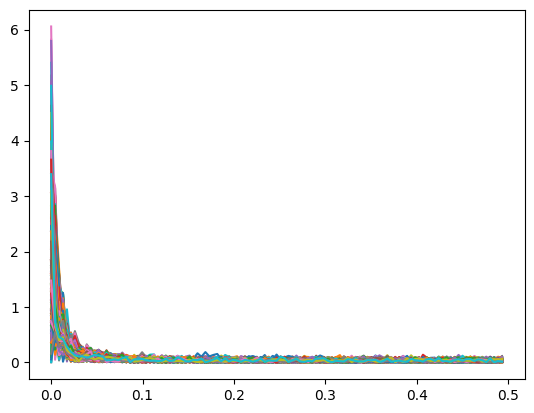

In [119]:
print(corrected_disps[0])
print(corrected_disps[:,1,0])

_, num_points, _ = corrected_disps.shape

for i in range(num_points):
    corrected_disps_x = corrected_disps[:,i,2]
    yf = fft(corrected_disps_x)
    N = len(corrected_disps_x)
    xf = fftfreq(N)[:N//2]

    mplt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
    mplt.grid()

mplt.show()

In [ ]:
fig, ax = mplt.subplots()
ax.set_xlim(0.0, 35.0)
*_, patches = ax.hist(np.linalg.norm(disps[0], axis=1), bins=50, color='blue')

def update_histogram(frame):
    global patches
    for p in patches:
        p.remove()

    *_, patches = ax.hist(np.linalg.norm(disps[frame], axis=1), bins=50, color='blue')
    return patches

ani = animation.FuncAnimation(fig=fig, func=update_histogram, frames=len(disps), interval=30)
ani.save("disp_length_over_time.gif")

In [ ]:
fig, ax = mplt.subplots()
ax.set_xlim(-30.0, 10.0)
ax.set_ylim(0, 200)

*_, x_patches = ax.hist(disps[0][:, 0], bins=50, alpha=0.33, color='blue')
*_, y_patches = ax.hist(disps[0][:, 1], bins=50, alpha=0.33, color='red')
*_, z_patches = ax.hist(disps[0][:, 2], bins=50, alpha=0.33, color='green')

def update_histogram(frame):
    global x_patches
    global y_patches
    global z_patches

    for p in x_patches:
        p.remove()
    for p in y_patches:
        p.remove()
    for p in z_patches:
        p.remove()

    *_, x_patches = ax.hist(disps[frame][:, 0], bins=50, alpha=0.33, color='blue')
    *_, y_patches = ax.hist(disps[frame][:, 1], bins=50, alpha=0.33, color='red')
    *_, z_patches = ax.hist(disps[frame][:, 2], bins=50, alpha=0.33, color='green')
    return (x_patches, y_patches, z_patches)

ani = animation.FuncAnimation(fig=fig, func=update_histogram, frames=len(disps), interval=30)
ani.save("disps_over_time.gif")
#mplt.show()


In [ ]:
cells = [("vertex", np.array([[i,] for i in range(len(centers))]))]
#mesh = mio.Mesh(centers, cells, point_data={"disps": disps[0]})
#mesh.write("/Users/zoeli/Documents/UVic/masters/other/fish/vtuFiles/foo.vtu")

for i, disp in enumerate(disps):
    mesh = mio.Mesh(centers, cells, point_data={"disps": disps[i], "outliers": corrected[i]})
    path = "/Users/zoeli/Documents/UVic/masters/other/fish/vtuFiles/disps" + str(i) + ".vtu"
    mesh.write(path)

In [35]:
def x_rotation_matrix(angle):
    return np.array([[1.0, 0.0, 0.0], [0.0, math.cos(angle), -math.sin(angle)], [0.0, math.sin(angle), math.cos(angle)]])

def y_rotation_matrix(angle):
    return np.array([[math.cos(angle), 0.0, math.sin(angle)],
                     [0.0, 1.0, 0.0],
                     [-math.sin(angle), 0.0, math.cos(angle)]])

def pca(points):
    transpose = points.transpose()
    length = len(points)
    centroid = np.array([sum(x) / length for x in transpose])
    
    Y_transpose = np.array([x - centroid for x in points])
    S = np.matmul(Y_transpose.transpose(), Y_transpose)
    
    eigenvalues, eigenvectors = np.linalg.eig(S)
    indices = np.argsort(eigenvalues)
    eigenvectors = eigenvectors[:,indices]
    return eigenvectors.transpose()

In [36]:
def align(centers, disps, do_pca, exclude):
    Q = centers[exclude]
    P = (centers[exclude] + disps[exclude])

    assert P.shape == Q.shape

    pcaP = pca(P)
    pcaQ = pca(Q)

    if np.dot(pcaP[0], pcaQ[0]) < 0.0:
        pcaP[0] *= -1.0
    if np.dot(pcaP[1], pcaQ[1]) < 0.0:
        pcaP[1] *= -1.0
    if np.dot(pcaP[2], pcaQ[2]) < 0.0:
        pcaP[2] *= -1.0

    R = pcaQ.T @ pcaP
    quaternion = Rotation.from_matrix(R)

    axis_angle = quaternion.as_rotvec(degrees=True)
    magnitude = np.linalg.norm(axis_angle)
    axis = np.array([axis_angle[0], axis_angle[1], 0.0])
    axis = magnitude * (axis / np.linalg.norm(axis))

    quaternion = Rotation.from_rotvec(axis, degrees=True)

    R = quaternion.as_matrix()
    rotatedP = (R @ P.T).T if do_pca else P
    
    centeredP = rotatedP - rotatedP.mean(axis=0)
    centeredQ = Q - Q.mean(axis=0)

    scale_x = np.linalg.lstsq(centeredP[:, 0].reshape(-1, 1), centeredQ[:, 0])[0]
    scale_y = np.linalg.lstsq(centeredP[:, 1].reshape(-1, 1), centeredQ[:, 1])[0]
    scale_z = np.linalg.lstsq(centeredP[:, 2].reshape(-1, 1), centeredQ[:, 2])[0]

    S = np.array([[scale_x[0], 0.0, 0.0],
                  [0.0, scale_y[0], 0.0],
                  [0.0, 0.0, scale_z[0]]])

    t = Q.mean(axis=0) - rotatedP.mean(axis=0).dot(S)

    return S, t, R

align(centers, disps[100], True, exclude_middle)

(array([[0.95705309, 0.        , 0.        ],
        [0.        , 0.95672667, 0.        ],
        [0.        , 0.        , 0.90266499]]),
 array([7.61975751, 3.85989087, 0.81848098]),
 array([[ 9.99990730e-01, -2.22681257e-05,  4.30584342e-03],
        [-2.22681257e-05,  9.99946511e-01,  1.03428874e-02],
        [-4.30584342e-03, -1.03428874e-02,  9.99937240e-01]]))

In [ ]:
test_disps = centers.copy()

test_disps[:,0] = 1.6 * test_disps[:,0]
test_disps[:,1] = 0.8 * test_disps[:,1]
test_disps[:,2] = 2.0 * test_disps[:,2]

for i in range(test_disps.shape[0]):
    test_disps[i, :] = test_disps[i, :] + np.array([0, 0, 10])
    
test_disps = (x_rotation_matrix(math.radians(10.0)) @ y_rotation_matrix(math.radians(-20.0)) @ (test_disps - np.array([159.0, 68.0, 0.0])).T).T + np.array([159.0, 68.0, 0.0])

#print(grid_rotation(test_disps).T @ np.array([0.0, 0.0, 10.0]))

M, t, R = align(centers, test_disps - centers, True, exclude_middle)
#tmp1 = (M @ ((R @ (test_disps - tR).T).T + tR).T).T + t
tmp1 = (M @ (R @ (test_disps).T)).T + t

print(M)
print(t)

pl = pv.Plotter()
pl.add_mesh(to_pyvista_mesh(centers), color='blue', point_size=3, render_points_as_spheres=True, name='centers')
#pl.add_mesh(to_pyvista_mesh(test_disps), color='red', point_size=3, render_points_as_spheres=True, name='test_disps')
pl.add_mesh(to_pyvista_mesh(tmp1), color='green', point_size=3, render_points_as_spheres=True, name='tmp1')
#pl.add_mesh(pv.Line((0, 0, 0), x_rotation_matrix(math.radians(-90)) @ grid_rotation(centers + disps[169]).T @ np.array([0.0, 0.0, 10.0])), color='red')
#pl.add_mesh(pv.Line((0, 0, 0), x_rotation_matrix(math.radians(-90)) @ grid_rotation(centers + disps[169]).T @ np.array([0.0, 10.0, 0.0])), color='green')
#pl.add_mesh(pv.Line((0, 0, 0), x_rotation_matrix(math.radians(-90)) @ grid_rotation(centers + disps[169]).T @ np.array([10.0, 0.0, 0.0])), color='blue')
#print(grid_rotation(centers).T)
#print(grid_rotation(centers + disps[169]).T)
#pl.add_mesh(pv.Line((0, 0, 0), grid_rotation(centers).T @ np.array([0.0, 0.0, 20.0])), color='red')
#pl.add_mesh(pv.Line((0, 0, 0), grid_rotation(centers).T @ np.array([0.0, 20.0, 0.0])), color='green')
#pl.add_mesh(pv.Line((0, 0, 0), grid_rotation(centers).T @ np.array([20.0, 0.0, 0.0])), color='blue')
pl.show()

In [37]:
def compute_align_disp(centers, disps, do_pca, do_scale_and_translation, exclude):
    M, t, R = align(centers, disps, do_pca, exclude)

    tmp = centers + disps
    tmp1 = (M @ (R @ tmp.T)).T + t if do_scale_and_translation else (R @ tmp.T).T

    return tmp1-centers, M, t, R

d, M, t, R1 = compute_align_disp(centers, disps[100], True, True, exclude_middle)
_, _, _, R2 = compute_align_disp(centers, disps[120], True, True, exclude_middle)

print(R1)
print(R2)

[[ 9.99990730e-01 -2.22681257e-05  4.30584342e-03]
 [-2.22681257e-05  9.99946511e-01  1.03428874e-02]
 [-4.30584342e-03 -1.03428874e-02  9.99937240e-01]]
[[ 9.99999871e-01  3.82464199e-06 -5.07264377e-04]
 [ 3.82464199e-06  9.99886311e-01  1.50786237e-02]
 [ 5.07264377e-04 -1.50786237e-02  9.99886182e-01]]


In [77]:
new_disps = []
Ms = []
ts = []
Rs = []
for i in range(len(disps)):
    d, M, t, R = compute_align_disp(centers, disps[i], True, True, exclude_middle)
    new_disps.append(d)
    Ms.append(M)
    ts.append(t)
    Rs.append(R)

In [78]:
new_corrected_disps = []
corrected_Ms = []
corrected_ts = []
corrected_Rs = []
for i in range(len(corrected_disps)):
    d, M, t, R = compute_align_disp(centers, corrected_disps[i], True, True, exclude_middle)
    new_corrected_disps.append(d)
    corrected_Ms.append(M)
    corrected_ts.append(t)
    corrected_Rs.append(R)

In [18]:
from scipy.ndimage import gaussian_filter

In [21]:
smoothed_corrected_Ms_diags = gaussian_filter(np.array(corrected_Ms).diagonal(axis1=1, axis2=2), sigma=(1, 0))
smoothed_corrected_Ms = np.array([np.diag(M_diag) for M_diag in smoothed_corrected_Ms_diags])
smoothed_corrected_ts = gaussian_filter(corrected_ts, sigma=(1, 0))

# TODO
smoothed_corrected_Rs = corrected_Rs
new_corrected_smoothed_disps = []

for i in range(len(corrected_disps)):
    tmp = centers + corrected_disps[i]
    tmp1 = (smoothed_corrected_Ms[i] @ (smoothed_corrected_Rs[i] @ tmp.T)).T + smoothed_corrected_ts[i]
    #new_corrected_smoothed_disps.append(tmp1 - centers)
    new_corrected_smoothed_disps.append(gaussian_filter(corrected_disps[i], sigma=(1, 0)))

In [79]:
new_corrected_disps_only_pca = []
for i in range(len(corrected_disps)):
    d, M, t, R = compute_align_disp(centers, corrected_disps[i], True, False, exclude_middle)
    new_corrected_disps_only_pca.append(d)

In [80]:
new_corrected_disps_only_scale_and_translation = []
for i in range(len(corrected_disps)):
    d, M, t, R = compute_align_disp(centers, corrected_disps[i], False, True, exclude_middle)
    new_corrected_disps_only_scale_and_translation.append(d)

In [81]:
new_corrected_disps_extra = []
for i in range(len(corrected_disps)):
    d, M, t, R = compute_align_disp(centers, corrected_disps[i], True, True, extra_exclude_middle)
    new_corrected_disps_extra.append(d)

new_corrected_disps_only_scale_and_translation_extra = []
for i in range(len(corrected_disps)):
    d, M, t, R = compute_align_disp(centers, corrected_disps[i], False, True, extra_exclude_middle)
    new_corrected_disps_only_scale_and_translation_extra.append(d)

new_corrected_disps_only_pca_extra = []
for i in range(len(corrected_disps)):
    d, M, t, R = compute_align_disp(centers, corrected_disps[i], True, False, extra_exclude_middle)
    new_corrected_disps_only_pca_extra.append(d)

NameError: name 'extra_exclude_middle' is not defined

In [82]:
pv.set_jupyter_backend('trame')

pl = pv.Plotter()
pl.add_mesh(to_pyvista_mesh(centers), color='blue', point_size=3, render_points_as_spheres=True, name='middle')

nd = disps[0].shape[0]
lines = np.hstack([[2, i, nd+i] for i in range(nd)])
corrected_lines = np.hstack([[2, i, nd+i] for i in range(nd)])

corrected_vertices = np.vstack([centers, centers + new_corrected_disps[0]])
corrected_ll = pv.PolyData(corrected_vertices, lines=corrected_lines)
corrected_ll['corrected'] = corrected[0]
pl.add_mesh(corrected_ll, name='corrected_line', scalars='corrected', cmap='winter')
#pl.add_mesh(corrected_ll, name='corrected_line', color='red')

#vertices = np.vstack([centers, centers + new_disps[0]])
#ll = pv.PolyData(vertices, lines=lines)
#ll['corrected'] = corrected[0]
#pl.add_mesh(ll, name='line', scalars='corrected', cmap='bwr')
#pl.add_mesh(ll, name='linea', color='green')

pl.add_mesh(pv.Line((0, 0, 0), corrected_Rs[0] @ np.array([0.0, 0.0, 20.0])), color='red', name='z')
pl.add_mesh(pv.Line((0, 0, 0), corrected_Rs[0] @ np.array([0.0, 20.0, 0.0])), color='green', name='y')
pl.add_mesh(pv.Line((0, 0, 0), corrected_Rs[0] @ np.array([20.0, 0.0, 0.0])), color='blue', name='x')

def callback(x):
    corrected_vertices = np.vstack([centers, centers + new_corrected_disps[int(x)]])
    corrected_ll = pv.PolyData(corrected_vertices, lines=corrected_lines)
    corrected_ll['corrected'] = corrected[int(x)]
    pl.add_mesh(corrected_ll, name='corrected_line', scalars='corrected', cmap='winter')
    #pl.add_mesh(corrected_ll, name='corrected_line', color='red')

    pl.add_mesh(pv.Line((0, 0, 0), corrected_Rs[int(x)] @ np.array([0.0, 0.0, 20.0])), color='red', name='z')
    pl.add_mesh(pv.Line((0, 0, 0), corrected_Rs[int(x)] @ np.array([0.0, 20.0, 0.0])), color='green', name='y')
    pl.add_mesh(pv.Line((0, 0, 0), corrected_Rs[int(x)] @ np.array([20.0, 0.0, 0.0])), color='blue', name='x')

    #vertices = np.vstack([centers, centers + new_disps[int(x)]])
    #ll = pv.PolyData(vertices, lines=lines)
    #ll['corrected'] = corrected[int(x)]
    #pl.add_mesh(ll, name='line', scalars='corrected', cmap='bwr')
    #pl.add_mesh(ll, name='linea', color='green')
    #pl.update()

    #print(Ms[int(x)])
    #print(ts[int(x)])

pl.add_slider_widget(callback, (0, len(disps)-1))
pl.show()
#interact(callback, x=(0, len(disps)-1, 1), continuous_update=False)




Widget(value='<iframe src="http://localhost:55637/index.html?ui=P_0x2046c53eed0_12&reconnect=auto" class="pyvi…

In [ ]:
f=206
mplt.hist(np.linalg.norm(np.array(disps[f]-new_disps[f]), axis=1), bins=50)
mplt.show()

In [ ]:
data = [1/np.linalg.det(M) for M in Ms]
mplt.plot(data)
mplt.xlabel('time')
mplt.ylabel('scale')
mplt.show()

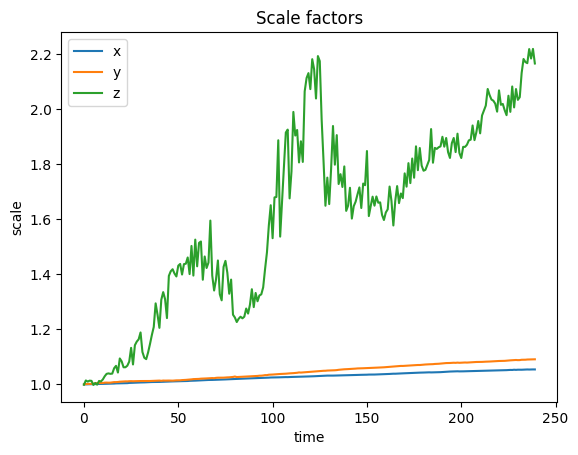

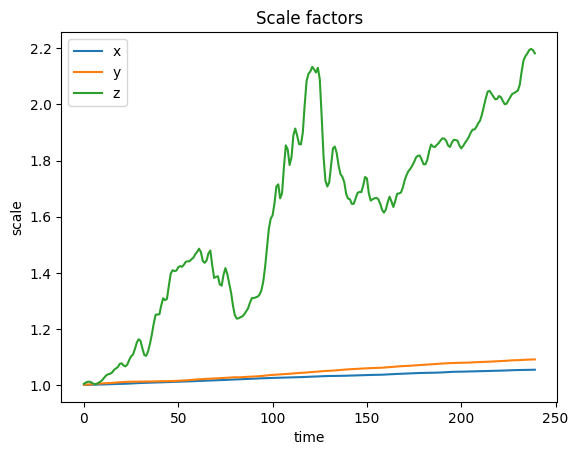

In [71]:
data = [1/M[0,0] for M in corrected_Ms]
mplt.plot(data, label='x')

data = [1/M[1,1] for M in corrected_Ms]
mplt.plot(data, label='y')

data = [1/M[2,2] for M in corrected_Ms]
mplt.plot(data, label='z')

mplt.xlabel('time')
mplt.ylabel('scale')
mplt.legend()
mplt.title('Scale factors')
mplt.show()

data = [1/M[0,0] for M in smoothed_corrected_Ms]
mplt.plot(data, label='x')

data = [1/M[1,1] for M in smoothed_corrected_Ms]
mplt.plot(data, label='y')

data = [1/M[2,2] for M in smoothed_corrected_Ms]
mplt.plot(data, label='z')

mplt.xlabel('time')
mplt.ylabel('scale')
mplt.legend()
mplt.title('Scale factors')
mplt.show()

In [ ]:
np.mean(np.linalg.norm(disps[-1][:,:2], axis=1)), np.mean(np.linalg.norm(new_disps[-1][:,:2], axis=1))

In [ ]:
disps[-1][:,:2]

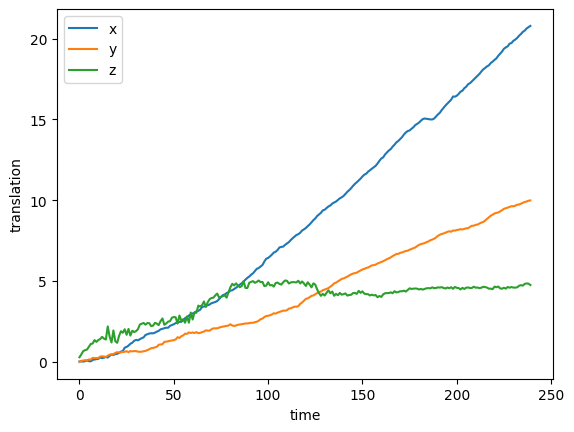

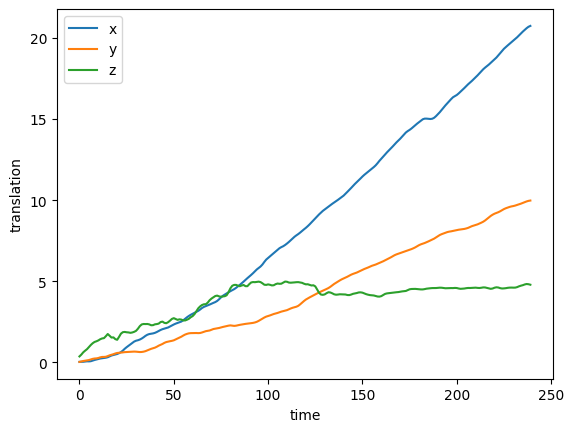

In [72]:
#print(ts)
data = [t[0] for t in corrected_ts]
mplt.plot(data, label='x')
data = [t[1] for t in corrected_ts]
mplt.plot(data, label='y')
data = [t[2] for t in corrected_ts]
mplt.plot(data, label='z')
mplt.legend()
mplt.xlabel('time')
mplt.ylabel('translation')
mplt.show()

#print(ts)
data = [t[0] for t in smoothed_corrected_ts]
mplt.plot(data, label='x')
data = [t[1] for t in smoothed_corrected_ts]
mplt.plot(data, label='y')
data = [t[2] for t in smoothed_corrected_ts]
mplt.plot(data, label='z')
mplt.legend()
mplt.xlabel('time')
mplt.ylabel('translation')
mplt.show()

In [ ]:
data = [np.mean(t[:, 0]) for t in new_corrected_disps]
mplt.plot(data, label='x')
data = [np.mean(t[:, 1]) for t in new_corrected_disps]
mplt.plot(data, label='y')
data = [np.mean(t[:, 2]) for t in new_corrected_disps]
mplt.plot(data, label='z')
mplt.legend()
mplt.xlabel('time')
mplt.ylabel('disp')
mplt.title('Mean disp after correction')
mplt.show()

In [ ]:
data = [np.mean(t[:, 0]) for t in disps]
mplt.plot(data, label='x')
data = [np.mean(t[:, 1]) for t in disps]
mplt.plot(data, label='y')
data = [np.mean(t[:, 2]) for t in disps]
mplt.plot(data, label='z')
mplt.legend()
mplt.xlabel('time')
mplt.ylabel('disp')
mplt.title('Mean disp before correction')
mplt.show()

In [44]:
from scipy.interpolate import RBFInterpolator


In [ ]:
default_json = { 
"geometry": {
        "mesh": "___",
        "volume_selection": 1
    },
"boundary_conditions": {
    "dirichlet_boundary": "___"
},
"materials": {
        "E": E,
        "id": 1,
        "nu": nu,
        "type": "LinearElasticity" if is_linear else "NeoHookean"
},
"output": {
    "json": "___",
    "directory": "___",
    "paraview": {
        "file_name": "___",
        "surface": True,
        "options": {
            "material": True,
            "forces": True
        },
        "vismesh_rel_area": 10000000
    }
}
}

In [ ]:
def generate_json(out, V, T, middle, bottom, top, centers, disps, index, eps):
    rbf = RBFInterpolator(centers, disps[index])
    disp = rbf(V[middle,:])

    with open(f"{out}disp_{index}.txt", "w") as f:
        for i in range(middle.shape[0]):
            f.write(f"{middle[i]} {disp[i, 0]} {disp[i, 1]} {disp[i, 2]}\n")
        for i in range(bottom.shape[0]):
            f.write(f"{bottom[i]} 0 0 0\n")
        for i in range(top.shape[0]):
            f.write(f"{top[i]} 0 0 0\n")

    mesh = mio.Mesh(points=V, cells={"tetra": T})
    mesh.write(f"{out}mesh.msh", file_format="gmsh")

    json = default_json.copy()
    json["geometry"]["mesh"] = f"mesh.msh"
    json["boundary_conditions"]["dirichlet_boundary"] = f"disp_{index}.txt"
    json["output"]["directory"] = out
    json["output"]["json"] = f"sim{index}.json"
    json["output"]["paraview"]["file_name"] = f"sim{index}.vtu"

    with open(f"{out}run_{index}.json", "w") as f:
        js.dump(json, f, indent=4)



generate_json("outnz/", V,T, middle, bottom, top, centers, disps, 239, eps)

In [ ]:
for i in range(len(disps)):
    generate_json("outnz/", V,T, middle, bottom, top, centers, new_disps, i, eps)

In [ ]:
index=200
sup.run([polyfem, "-j", f"outnz/run_{index}.json"], check=True)

In [83]:
rbf_disps = []

for i, disp in enumerate(disps):
    corrected_tf = [val < 0.5 for val in corrected[i]]
    rbf = RBFInterpolator(centers[corrected_tf], new_corrected_disps[i][corrected_tf])
    rbf_disp = rbf(centers)
    rbf_disps.append(rbf_disp)

In [66]:
pl = pv.Plotter()

pl.add_mesh(to_pyvista_mesh(centers), color='blue', point_size=3, render_points_as_spheres=True, name='middle')

nd = centers.shape[0]
lines = np.hstack([[2, i, nd+i] for i in range(nd)])

#corrected_tf = [val < 0.5 for val in corrected[0]]
#rbf = RBFInterpolator(centers[corrected_tf], new_disps[0][corrected_tf])
#rbf_disp = rbf(centers)

vertices = np.vstack([centers, centers + rbf_disps[0]])
ll = pv.PolyData(vertices, lines=lines)
pl.add_mesh(ll, name='line', color='green')

pl.camera_position = 'xz'
pl.camera.elevation = 25
def callback(x):
    #corrected_tf = [val < 0.5 for val in corrected[x]]
    #rbf = RBFInterpolator(centers[corrected_tf], new_disps[x][corrected_tf])
    #rbf_disp = rbf(centers)

    vertices = np.vstack([centers, centers + rbf_disps[x]])
    ll = pv.PolyData(vertices, lines=lines)
    pl.add_mesh(ll, name='line', color='green')
    
    pl.update()
    #pl.camera_position = 'xy'

pl.show()
interact(callback, x=(0, len(disps)-1, 1))

Widget(value='<iframe src="http://localhost:55637/index.html?ui=P_0x2046c53d520_10&reconnect=auto" class="pyvi…

interactive(children=(IntSlider(value=119, description='x', max=239), Output()), _dom_classes=('widget-interac…

<function __main__.callback(x)>

In [84]:
cells = [("vertex", np.array([[i,] for i in range(len(centers))]))]

for i, disp in enumerate(disps):
    mesh = mio.Mesh(centers, cells, point_data={
        "original_disps": disps[i], 
        "outlier_identification": corrected[i], 
        "corrected_pca_scale_translation": new_corrected_disps[i], 
        "corrected_scale_translation": new_corrected_disps_only_scale_and_translation[i], 
        "corrected_pca": new_corrected_disps_only_pca[i], 
       # "corrected_pca_scale_translation_with_smoothing": new_corrected_smoothed_disps[i], 
        "rbf": rbf_disps[i]
    })
    path = "/Users/zoeli/Documents/UVic/masters/other/fish/vtuFiles/disps" + str(i) + ".vtu"
    mesh.write(path)

In [ ]:
pl = pv.Plotter(notebook=False, off_screen=True)
pl.add_mesh(to_pyvista_mesh(centers), color='blue', point_size=3, render_points_as_spheres=True, name='middle')

nd = centers.shape[0]
lines = np.hstack([[2, i, nd+i] for i in range(nd)])

vertices = np.vstack([centers, centers + rbf_disps[0]])
ll = pv.PolyData(vertices, lines=lines)
pl.add_mesh(ll, name='line', color='green')

actor = pl.add_text(str(0), position='upper_right')
pl.camera_position = 'xz'
pl.camera.elevation = 25

# Open a gif
pl.open_gif("updated.gif")

# Update Z and write a frame for each updated position
nframe = 15
for index in range(len(rbf_disps)):
    vertices = np.vstack([centers, centers + rbf_disps[index]])
    ll = pv.PolyData(vertices, lines=lines)
    pl.add_mesh(ll, name='line', color='green')

    actor.set_text('upper_right', str(index))

    # Write a frame. This triggers a render.
    pl.write_frame()

# Closes and finalizes movie
pl.close()

In [ ]:
pl = pv.Plotter(notebook=False, off_screen=True)
pl.add_mesh(to_pyvista_mesh(centers), color='blue', point_size=3, render_points_as_spheres=True, name='middle')

actor = pl.add_text(str(0), position='upper_right')
pl.camera_position = 'xz'
pl.camera.elevation = 45

# Open a gif
pl.open_gif("test.gif")

# Update Z and write a frame for each updated position
nframe = 15
for index in range(len(rbf_disps)):
    pl.add_mesh(to_pyvista_mesh(centers + rbf_disps[index]), color='blue', point_size=3, render_points_as_spheres=True, name='middle')

    actor.set_text('upper_right', str(index))

    # Write a frame. This triggers a render.
    pl.write_frame()

# Closes and finalizes movie
pl.close()